Gradient Boosting Regression on Diabetes Dataset - 4/11/2026 - JOSZIM1500

In [4]:
from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# NOTEBOOK TITLE
# ============================================================
display(Markdown("# Gradient Boosting Regression on Diabetes Dataset"))
display(Markdown("Date 4/11/2026"))
display(Markdown("Student ID JOSZIM1500"))

# ============================================================
# STEP 1: Load and Explore the Dataset
# ============================================================
display(Markdown("## Step 1: Load and Explore the Dataset"))

diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")
df = pd.concat([X, y], axis=1)

df.info()
df.describe()


# Gradient Boosting Regression on Diabetes Dataset

Date 4/11/2026

Student ID JOSZIM1500

## Step 1: Load and Explore the Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:

# ============================================================
# STEP 2: Preprocess the Data
# ============================================================
display(Markdown("## Step 2: Preprocess the Data"))

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


## Step 2: Preprocess the Data

Training samples: 353
Testing samples: 89


In [6]:
# ============================================================
# STEP 3: Implement Gradient Boosting Regression
# ============================================================
display(Markdown("## Step 3: Implement Gradient Boosting Regression"))

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

## Step 3: Implement Gradient Boosting Regression

In [7]:

# ============================================================
# STEP 4: Evaluate the Model
# ============================================================
display(Markdown("## Step 4: Evaluate the Model"))

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared Score (R²):", r2)



## Step 4: Evaluate the Model

Mean Squared Error (MSE): 2898.4366729135227
R-squared Score (R²): 0.4529343796683364


In [8]:

# ============================================================
# STEP 5: Apply GridSearchCV for Hyperparameter Tuning
# ============================================================
display(Markdown("## Step 5: Apply GridSearchCV for Hyperparameter Tuning"))

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 4, 5]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


## Step 5: Apply GridSearchCV for Hyperparameter Tuning

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


In [9]:

# ============================================================
# STEP 6: Evaluate the Adjusted Model
# ============================================================
display(Markdown("## Step 6: Evaluate the Adjusted Model"))

best_gbr = grid.best_estimator_
y_pred_grid = best_gbr.predict(X_test)

mse_grid = mean_squared_error(y_test, y_pred_grid)
r2_grid = r2_score(y_test, y_pred_grid)

print("Adjusted MSE:", mse_grid)
print("Adjusted R²:", r2_grid)


## Step 6: Evaluate the Adjusted Model

Adjusted MSE: 2871.8519574980814
Adjusted R²: 0.4579521135267304


In [10]:

# ============================================================
# STEP 7: Apply Early Stopping
# ============================================================
display(Markdown("## Step 7: Apply Early Stopping"))

early_gbr = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=3,
    validation_fraction=0.2,
    n_iter_no_change=10,
    tol=0.01,
    random_state=42
)

early_gbr.fit(X_train, y_train)

y_pred_early = early_gbr.predict(X_test)

mse_early = mean_squared_error(y_test, y_pred_early)
r2_early = r2_score(y_test, y_pred_early)

print("Early Stopping MSE:", mse_early)
print("Early Stopping R²:", r2_early)


## Step 7: Apply Early Stopping

Early Stopping MSE: 2830.467552525175
Early Stopping R²: 0.4657632157633723


## Step 8: Compare GridSearchCV and Early Stopping

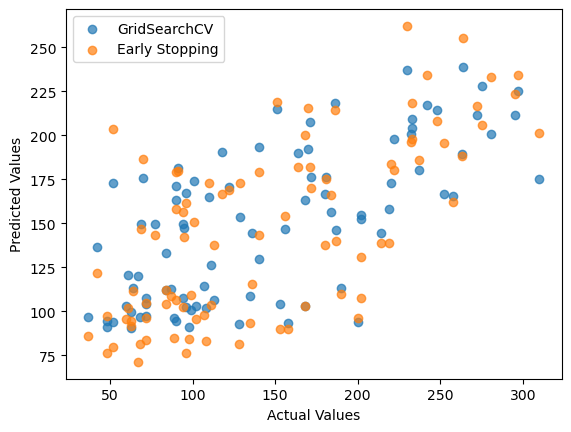

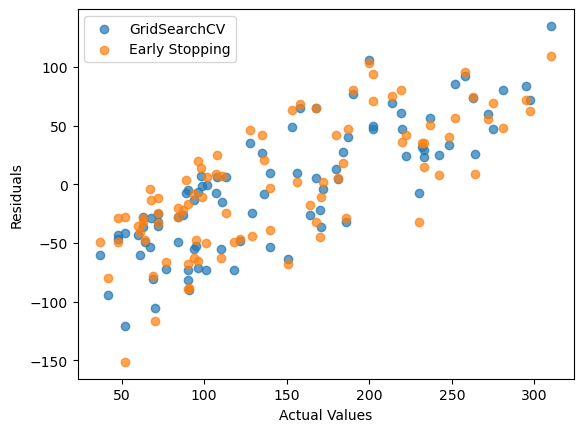

In [11]:

# ============================================================
# STEP 8: Compare GridSearchCV and Early Stopping
# ============================================================
display(Markdown("## Step 8: Compare GridSearchCV and Early Stopping"))

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred_grid, label="GridSearchCV", alpha=0.7)
plt.scatter(y_test, y_pred_early, label="Early Stopping", alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

# Residuals
plt.figure()
plt.scatter(y_test, y_test - y_pred_grid, label="GridSearchCV", alpha=0.7)
plt.scatter(y_test, y_test - y_pred_early, label="Early Stopping", alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.legend()
plt.show()
